[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/open-energy-transition/pypsa-ppa/blob/main/notebooks/pypsa_ppa_worked_example_march_2025_csv.ipynb)

# PyPSA worked example: modelling a renewable portfolio under a PPA

This notebook shows how **PyPSA** can be used not only for whole-grid studies, but also for a **commercial dispatch** problem: how a renewable portfolio operates when dispatch is optimised against the conditions of a PPA.

---

## What is a Power Purchase Agreement?

A **Power Purchase Agreement (PPA)** is a long-term contract between a power producer and a buyer (the *offtaker*) that sets out the terms under which electricity is sold - the price, volume, delivery obligations, and what happens when those obligations are not met.

PPAs have become a central instrument in the global energy transition:

- **Enabling renewable project finance.** Developers use PPAs to secure predictable revenue that underpins project debt, reducing the cost of capital for new wind and solar capacity. Without a PPA, a merchant project must absorb the full volatility of wholesale electricity prices, which makes financing harder and more expensive.
- **Supporting corporate clean energy procurement.** Large energy consumers - data centres, manufacturers, retailers - use PPAs to source renewable electricity at contracted prices, supporting net-zero commitments and RE100 targets.
- **Managing price and volume risk.** PPAs allow both producers and buyers to hedge against spot price volatility. The contract allocates risk between counterparties: who bears the cost of a price spike? Who is exposed if the wind doesn't blow?

### PPA structures vary widely

Not all PPAs work the same way. Key dimensions include:

| Dimension | Common variants |
|---|---|
| **Delivery structure** | Pay-as-produced (variable output), baseload or shaped, 24/7 hourly matched |
| **Settlement** | Physical (direct supply to buyer), virtual / financial (contract-for-difference settled against spot) |
| **Duration** | Short-term (1–5 years) through to long-term (10–20+ years) |
| **Offtake profile** | Flat MW demand, shaped to the buyer's load, or a defined hourly schedule |
| **Balancing obligations** | Who covers shortfall or excess, and at what penalty rate? |

The specific contractual terms - delivery obligations, allowed shortfall, penalty regimes, market interaction rules - directly shape how a renewable portfolio should be operated. This is where energy system modelling becomes valuable.

---

## Why model a PPA with PyPSA?

PyPSA is often used to model entire energy grids or grid regions, but it can also be used to model how particular plants would operate under PPAs.

In this framing, we are effectively modelling the **commercial flows of power**. Dispatch is optimised while considering the conditions of the offtake contract.

This is useful for renewable energy plant developers who are building grid-connected plants and intend to sell power under an offtake agreement. PyPSA modelling can then be used to:

- size the plant and storage configuration,
- test dispatch strategies,
- compare PPA structures, and
- run scenario analysis to help quantify merchant and contractual risk.

---

## Network design used in this notebook

The network includes:

1. **Physical generation and storage assets** represented with generators, storage units, buses and links up to the contractual delivery point.
2. A **PPA offtake load** representing the customer load quantum and hourly profile under the contract.
3. Two **commercial balancing generators** at the PPA delivery bus:
   - **Penalty**: covers unmet PPA demand at a high marginal cost equal to the contractual penalty.
   - **Allowed shortfall**: covers permitted non-delivery at very low marginal cost, but is capped by an aggregate contract constraint.
4. **Market buy and sell components** so the portfolio can interact with the wider market:
   - **Buy from market** represents purchases used to support PPA fulfilment.
   - **Sell to market** represents excess generation sold outside the PPA.
5. **Intermediate buses and links** so the commercial energy flows can be traced and reported clearly.



## Implementation roadmap

This notebook follows these steps:

1. Install the required packages in Colab.
2. Define the worked example and the model variables.
3. Load March 2025 hourly time series from a CSV file placed in a relative `data/` folder.
4. Validate and prepare those time series for the PyPSA model.
5. Build the PyPSA network with buses, generators, storage, loads and links.
6. Validate the network structure and generate a topology diagram with **PyPSATopo**.
7. Add the PPA SLA constraints using **custom Linopy constraints** via `n.optimize.create_model()`.
8. Solve the model.
9. Check that the contractual constraints are respected.
10. Report operational and commercial results, including charts.


In [1]:

# Colab install cell
# Run this once in Google Colab before executing the rest of the notebook.
%pip install -q pypsa pypsatopo pyarrow highspy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 358.3/358.3 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.0/117.0 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.7/44.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 33.3 MB/s eta 0:00:00



## Worked example scenario

An Independent Power Producer (IPP) is building a small portfolio of assets:

- **150 MW** onshore wind,
- **200 MW AC** solar PV,
- **60 MW / 240 MWh** co-located BESS.

An offtaker offers a PPA to take up to **100 MW in every hour**. The offtaker asks the IPP to meet **75% of that flat 100 MW demand on average over the year**.

The PPA tariff is **$100/MWh**. Under the PPA, the IPP must pay **1.5x the tariff** for each MWh of shortfall beyond the allowed level. The IPP is allowed to supplement supply with power purchased from the market, subject to an aggregate cap.

For this worked example, we model **one month of hourly data** for **March**.


In [2]:

### NOTE FOR MS: Add column headings to df. More explanatory comments.

import math
from pathlib import Path

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import SVG, display, Markdown

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# -----------------------------
# Core scenario variables
# -----------------------------
onsw_mw = 150.0
pv_mw = 200.0
bess_mw = 60.0
bess_mwh = 240.0
bess_max_hours = bess_mwh / bess_mw

ppaload_mw = 100.0
ppa_price = 100.0
pen_mult = 1.5

# Contract shares
required_delivery_share = 0.75          # of nominal PPA demand over the period
allowed_shortfall_share = 1 - required_delivery_share  # 25%
market_buy_share = 0.05                 # explicit implementation requirement in step 7
scenario_market_buy_share = 0.10        # from the scenario text; not used in the constrained solve

# Commercial limits / helper capacities
maxbuy_mw = ppaload_mw
maxsell_mw = onsw_mw + pv_mw + bess_mw
market_spread = 0.10                    # small friction to avoid buy-sell circular flows
chosen_day = "2025-03-15"

variables_df = pd.DataFrame([
    ("onsw_mw", onsw_mw, "MW", "Onshore wind installed capacity"),
    ("pv_mw", pv_mw, "MWac", "Solar PV installed capacity"),
    ("bess_mw", bess_mw, "MW", "BESS power capacity"),
    ("bess_mwh", bess_mwh, "MWh", "BESS energy capacity"),
    ("bess_max_hours", bess_max_hours, "hours", "BESS storage duration"),
    ("ppaload_mw", ppaload_mw, "MW", "Hourly PPA offtake load"),
    ("ppa_price", ppa_price, "$/MWh", "PPA tariff"),
    ("pen_mult", pen_mult, "x", "Penalty multiplier applied to PPA tariff"),
    ("required_delivery_share", required_delivery_share, "share", "Required delivery share over the modelled period"),
    ("allowed_shortfall_share", allowed_shortfall_share, "share", "Allowed shortfall share over the modelled period"),
    ("market_buy_share", market_buy_share, "share", "Implemented aggregate cap on market purchases"),
    ("scenario_market_buy_share", scenario_market_buy_share, "share", "Scenario-text value for market purchases"),
    ("maxbuy_mw", maxbuy_mw, "MW", "Upper bound for the BuyFromMarket asset"),
    ("maxsell_mw", maxsell_mw, "MW", "Upper bound for the SellToMarket pathway"),
])

variables_df


,0,1,2,3
0,onsw_mw,150.00,MW,Onshore wind installed capacity
1,pv_mw,200.00,MWac,Solar PV installed capacity
2,bess_mw,60.00,MW,BESS power capacity
3,bess_mwh,240.00,MWh,BESS energy capacity
4,bess_max_hours,4.00,hours,BESS storage duration
5,ppaload_mw,100.00,MW,Hourly PPA offtake load
6,ppa_price,100.00,$/MWh,PPA tariff
7,pen_mult,1.50,x,Penalty multiplier applied to PPA tariff
8,required_delivery_share,0.75,share,Required delivery share over the modelled period
9,allowed_shortfall_share,0.25,share,Allowed shortfall share over the modelled period



## Worked example variables

The table below defines the variables used in the code. Time-series variables are loaded later from the CSV input file.


In [3]:
### NOTE FOR MS: Add column headings. A bit more explanation (Storage unit efficiencies?)

variables_df

,0,1,2,3
0,onsw_mw,150.00,MW,Onshore wind installed capacity
1,pv_mw,200.00,MWac,Solar PV installed capacity
2,bess_mw,60.00,MW,BESS power capacity
3,bess_mwh,240.00,MWh,BESS energy capacity
4,bess_max_hours,4.00,hours,BESS storage duration
5,ppaload_mw,100.00,MW,Hourly PPA offtake load
6,ppa_price,100.00,$/MWh,PPA tariff
7,pen_mult,1.50,x,Penalty multiplier applied to PPA tariff
8,required_delivery_share,0.75,share,Required delivery share over the modelled period
9,allowed_shortfall_share,0.25,share,Allowed shortfall share over the modelled period


## Scenario overview diagrams

The two diagrams below visualise the scenario described above. Run this cell after the variables cell to generate them.

- **Figure 1** shows how the physical assets connect to the IPP aggregation bus and how energy is then routed to the PPA offtaker, the spot market, or absorbed by the penalty / shortfall regime.
- **Figure 2** shows the contractual delivery obligation as a proportion of total contracted load, and where the penalty threshold sits.


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

# ── Figure 1: Portfolio structure and commercial flow ─────────────────────────

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_xlim(0, 13)
ax.set_ylim(0.2, 7.5)
ax.axis('off')

BW, BH = 2.2, 0.82

def _box(cx, cy, text, fc, tc='white', fs=8.5):
    ax.add_patch(FancyBboxPatch(
        (cx - BW / 2, cy - BH / 2), BW, BH,
        boxstyle='round,pad=0.1', facecolor=fc, edgecolor='white',
        linewidth=1.5, alpha=0.92, zorder=3,
    ))
    ax.text(cx, cy, text, ha='center', va='center', fontsize=fs,
            color=tc, fontweight='bold', multialignment='center', zorder=4)

def _arrow(x1, y1, x2, y2, label='', lc='#555', rad=0):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1), zorder=2,
                arrowprops=dict(arrowstyle='->', color=lc, lw=1.5,
                                connectionstyle=f'arc3,rad={rad}'))
    if label:
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mx, my + 0.2, label, ha='center', va='bottom',
                fontsize=7.5, color=lc, style='italic')

XA, XM, XR = 2.0, 6.5, 11.0  # column x-positions

# Physical assets (left column)
_box(XA, 6.0, f'Onshore Wind\n{onsw_mw:.0f} MW', '#388E3C')
_box(XA, 4.6, f'Solar PV\n{pv_mw:.0f} MW AC', '#F57C00')
_box(XA, 3.2, f'BESS\n{bess_mw:.0f} MW / {bess_mwh:.0f} MWh', '#1565C0')
_box(XA, 1.4, 'Spot market\n(buy)', '#546E7A')

# IPP aggregation bus (centre)
_box(XM, 4.0, 'IPP\nAggregation\nBus', '#6A1B9A', fs=9)

# Contractual outcomes (right column)
_box(XR, 6.0, f'PPA Offtaker\n{ppaload_mw:.0f} MW flat', '#BF360C')
_box(XR, 4.4, f'Allowed shortfall\n≤ {allowed_shortfall_share * 100:.0f}% of load', '#EF6C00', tc='#333')
_box(XR, 2.8, f'Penalty\n{pen_mult:.1f}× ${ppa_price:.0f} = ${ppa_price * pen_mult:.0f}/MWh', '#B71C1C')
_box(XR, 1.2, 'Excess sold\nto market', '#37474F')

# Assets → aggregation
_arrow(XA + BW / 2, 6.0, XM - BW / 2, 4.3)
_arrow(XA + BW / 2, 4.6, XM - BW / 2, 4.1)
_arrow(XA + BW / 2, 3.2, XM - BW / 2, 3.8)

# Market buy → aggregation (curved to avoid overlap with asset arrows)
_arrow(XA + BW / 2, 1.4, XM - BW / 2, 3.6,
       label=f'≤ {market_buy_share * 100:.0f}% of delivery', lc='#546E7A', rad=0.15)

# Aggregation → PPA delivery
_arrow(XM + BW / 2, 4.3, XR - BW / 2, 5.7,
       label=f'${ppa_price:.0f}/MWh tariff', lc='#BF360C')

# Aggregation → excess market sell
_arrow(XM + BW / 2, 3.7, XR - BW / 2, 1.4,
       label='excess', lc='#37474F')

# Shortfall gap (vertical, right column)
_arrow(XR, 6.0 - BH / 2, XR, 4.4 + BH / 2, label='shortfall', lc='#EF6C00')

# Shortfall → penalty if aggregate cap exceeded
_arrow(XR, 4.4 - BH / 2, XR, 2.8 + BH / 2, label='if cap exceeded', lc='#B71C1C')

# Column headers
for x, txt in [
    (XA, 'Physical portfolio'),
    (XM, 'Commercial\naggregation'),
    (XR, 'Contractual\noutcomes'),
]:
    ax.text(x, 7.1, txt, ha='center', va='center', fontsize=10,
            color='#333', fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#F5F5F5', edgecolor='#BDBDBD'))

ax.set_title('Portfolio structure and commercial energy flows', fontsize=13, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'portfolio_flow_diagram.png', dpi=150, bbox_inches='tight')
plt.show()


# ── Figure 2: PPA delivery obligation ────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(10, 2.8))
ax2.set_xlim(-2, 114)
ax2.set_ylim(0.3, 3.2)
ax2.axis('off')

BY, BH2 = 1.6, 0.9

ax2.barh(BY, required_delivery_share * 100, height=BH2, left=0,
         color='#388E3C', alpha=0.88)
ax2.barh(BY, allowed_shortfall_share * 100, height=BH2,
         left=required_delivery_share * 100, color='#FFA726', alpha=0.88)

ax2.text(required_delivery_share * 50, BY,
         f'Must deliver on average\n≥ {required_delivery_share * 100:.0f}% of contracted load',
         ha='center', va='center', fontsize=10, fontweight='bold', color='white')
ax2.text(required_delivery_share * 100 + allowed_shortfall_share * 50, BY,
         f'Permitted gap\n≤ {allowed_shortfall_share * 100:.0f}%',
         ha='center', va='center', fontsize=9.5, fontweight='bold', color='#333')

ax2.annotate(
    f'Beyond {allowed_shortfall_share * 100:.0f}%: penalty\n'
    f'{pen_mult:.1f}× tariff = ${ppa_price * pen_mult:.0f}/MWh',
    xy=(100, BY), xytext=(103, BY),
    ha='left', va='center', fontsize=9, color='#B71C1C',
    arrowprops=dict(arrowstyle='->', color='#B71C1C', lw=1.3),
)

tick_y = BY - BH2 / 2 - 0.15
ax2.axhline(tick_y, xmin=0.018, xmax=0.895, color='#555', linewidth=0.9)
for pct, lbl in [
    (0, '0%'),
    (required_delivery_share * 100, f'{required_delivery_share * 100:.0f}%'),
    (100, '100%'),
]:
    ax2.plot(pct, tick_y, '|', color='#555', markersize=6, markeredgewidth=1.5)
    ax2.text(pct, tick_y - 0.28, lbl, ha='center', fontsize=9, color='#555')

ax2.text(50, tick_y - 0.62,
         'Share of total contracted load (aggregate over period)',
         ha='center', fontsize=9, color='#777', style='italic')

fig2.suptitle(
    f'PPA delivery obligation — {ppaload_mw:.0f} MW flat offtake, '
    f'{required_delivery_share * 100:.0f}% minimum fulfilment',
    fontsize=11, fontweight='bold',
)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'ppa_obligation_diagram.png', dpi=150, bbox_inches='tight')
plt.show()



## Worked example network components

### Buses

| Name | Description |
|---|---|
| `Bus_OnshoreWind` | Onshore wind plant electrical bus |
| `Bus_PVBESS` | Shared PV and BESS electrical bus |
| `Bus_IPPGeneration` | Aggregation bus for portfolio generation before delivery decisions |
| `Bus_BuyFromMarket` | Commercial bus for purchased market energy |
| `Bus_SellToMarket` | Commercial bus for excess energy sold to the market |
| `Bus_PPAOfftake` | Delivery point under the PPA |

### Loads

| Name | bus | `p_set` | Description |
|---|---|---:|---|
| `Load_PPAOfftake` | `Bus_PPAOfftake` | `ppaload_mw` | Contracted hourly offtake load |

### Generators

| Name | bus | `p_nom` | `p_max_pu` | `marginal_cost` | Extra attributes | Description |
|---|---|---:|---|---|---|---|
| `Gen_OnshoreWind` | `Bus_OnshoreWind` | `onsw_mw` | `ts_WindGen` | `0.1` |  | Wind generation asset |
| `Gen_PV` | `Bus_PVBESS` | `pv_mw` | `ts_PVGen` | `0.01` |  | PV generation asset |
| `Gen_BuyFromMarket` | `Bus_BuyFromMarket` | `maxbuy_mw` | `1` | `ts_MktPrice + spread` |  | Market purchases used to support delivery |
| `Gen_SellToMarket` | `Bus_SellToMarket` | `maxsell_mw` | `1` | `-(ts_MktPrice - spread)` | `sign=-1` | Sink representing energy sold to market |
| `Gen_Penalty` | `Bus_PPAOfftake` | `ppaload_mw` | `1` | `ppa_price * pen_mult` |  | Expensive fallback representing penalised shortfall |
| `Gen_AllowedShortfall` | `Bus_PPAOfftake` | `ppaload_mw` | `1` | `0.001` |  | Permitted shortfall, constrained in aggregate |

### Storage units

| Name | bus | `p_nom` | `max_hours` | `efficiency_store` | `efficiency_dispatch` | Description |
|---|---|---:|---:|---:|---:|---|
| `SU_BESS` | `Bus_PVBESS` | `bess_mw` | `4` | `0.9` | `0.9` | Co-located battery at the PV bus |

### Links

| Name | `bus0` | `bus1` | `p_nom` | `marginal_cost` | Description |
|---|---|---|---:|---:|---|
| `OnshoreWind_to_IPPGeneration` | `Bus_OnshoreWind` | `Bus_IPPGeneration` | `onsw_mw` | `0` | Transfers wind output to the portfolio aggregation bus |
| `PVBESS_to_IPPGeneration` | `Bus_PVBESS` | `Bus_IPPGeneration` | `pv_mw + bess_mw` | `0` | Transfers PV and BESS output to the portfolio aggregation bus |
| `BuyFromMarket_to_IPPGeneration` | `Bus_BuyFromMarket` | `Bus_IPPGeneration` | `maxbuy_mw` | `0` | Moves purchased market power into the portfolio account |
| `IPPGen_to_SellToMarket` | `Bus_IPPGeneration` | `Bus_SellToMarket` | `maxsell_mw` | `0` | Routes excess energy to the market sell bus |
| `IPPGen_to_PPAOfftake` | `Bus_IPPGeneration` | `Bus_PPAOfftake` | `ppaload_mw` | `-ppa_price` | Routes delivered energy to the PPA delivery point and carries the contractual value of delivery |

### Design note

The `IPPGen_to_PPAOfftake` link uses `marginal_cost = -ppa_price` so that the optimizer values delivery under the PPA. This is what makes the model behave like a **commercial dispatch** problem rather than a purely physical feasibility problem.



## Load March 2025 hourly input data from CSV

This worked example now uses externally prepared hourly data from a CSV file instead of synthetic data generation.

Expected file location in Colab: `data/march_2025_pypsa_timeseries.csv`

Required columns:

- `timestamp`
- `ts_PVGen`
- `ts_WindGen`
- `ts_NSWPrice`

Any additional columns in the CSV are preserved but are not required by this worked example.


In [5]:
### NOTE FOR MS: Explain source of generation data. Format numbers here and add units consistently.


# Load hourly time series from CSV in a relative folder for Google Colab
csv_path = DATA_DIR / "march_2025_pypsa_timeseries.csv"

if not csv_path.exists():
    raise FileNotFoundError(
        f"Could not find the input CSV at {csv_path.resolve()}. "
        "Create the relative 'data' folder in Colab and upload the CSV there before running this cell."
    )

# CSV data is sourced from NEM data reported from AEMO in March 2025,
# and references the preparation notebook `nemosis_march_2025_timeseries_tested.ipynb`.
ts_raw = pd.read_csv(csv_path)

required_columns = ["timestamp", "ts_PVGen", "ts_WindGen", "ts_NSWPrice"]
missing_columns = [col for col in required_columns if col not in ts_raw.columns]
if missing_columns:
    raise ValueError(f"Missing required CSV columns: {missing_columns}")

ts = ts_raw.copy()
ts["timestamp"] = pd.to_datetime(ts["timestamp"])
ts = ts.sort_values("timestamp").set_index("timestamp")
ts.index.name = "snapshot"

# Align market-price naming with the rest of the worked example notebook.
ts["ts_MktPrice"] = ts["ts_NSWPrice"]

# Flat offtake profile retained from the original worked example.
ts["ppaload_mw"] = ppaload_mw

display(Markdown(f"**Loaded input data:** `{csv_path}`"))
ts.head()


**Loaded input data:** `data/march_2025_pypsa_timeseries.csv`

,ts_PVGen,ts_WindGen,ts_NSWPrice,BODWF1_mw,COLEASF1_mw,ts_MktPrice,ppaload_mw
snapshot,,,,,,,
2025-03-01 00:00:00,0.0,0.099795,118.817710,11.296827,0.0,118.817710,100.0
2025-03-01 01:00:00,0.0,0.104813,133.895803,11.864790,0.0,133.895803,100.0
2025-03-01 02:00:00,0.0,0.090035,117.472044,10.191949,0.0,117.472044,100.0
2025-03-01 03:00:00,0.0,0.072909,121.250668,8.253267,0.0,121.250668,100.0
2025-03-01 04:00:00,0.0,0.155039,127.117672,17.550361,0.0,127.117672,100.0


In [6]:
### NOTE FOR MS: More explanation on what these charts are saying


# Quick validation charts for the March 2025 input data
fig = px.line(
    ts[["ts_WindGen", "ts_PVGen"]].reset_index().melt(id_vars="snapshot", var_name="series", value_name="value"),
    x="snapshot",
    y="value",
    color="series",
    title="March 2025 renewable availability profiles from CSV",
)
fig.update_layout(yaxis_title="Availability (p_max_pu)")
fig.show()

fig = px.line(
    ts.reset_index(),
    x="snapshot",
    y="ts_MktPrice",
    title="March 2025 NSW market price profile from CSV",
)
fig.update_layout(yaxis_title="$/MWh")
fig.show()



## Review the prepared time series

At this point the notebook has loaded and normalised the CSV input into the `ts` DataFrame used by the PyPSA model.


In [7]:
### NOTE FOR MS: Number formatting. Explain some useful outputs we can take away from this.

# Confirm the modelling dataset
ts.describe(include='all').T


,count,mean,std,min,25%,50%,75%,max
ts_PVGen,744.0,0.221211,0.320855,0.000000,0.000000,0.000000,0.511888,0.880503
ts_WindGen,744.0,0.371891,0.288505,0.000000,0.088751,0.346776,0.624206,0.933168
ts_NSWPrice,744.0,89.967117,178.282524,-29.399416,54.190752,76.719948,102.544291,3216.593458
BODWF1_mw,744.0,42.098042,32.658726,0.000000,10.046644,39.255000,70.660116,105.634632
COLEASF1_mw,744.0,33.181678,48.128299,0.000000,0.000000,0.000000,76.783160,132.075417
ts_MktPrice,744.0,89.967117,178.282524,-29.399416,54.190752,76.719948,102.544291,3216.593458
ppaload_mw,744.0,100.000000,0.000000,100.000000,100.000000,100.000000,100.000000,100.000000



## Create the PyPSA network


In [14]:
### NOTE FOR MS: Explain this step

import pypsa

n = pypsa.Network()
n.set_snapshots(ts.index)

# Buses
for bus_name in [
    "Bus_OnshoreWind",
    "Bus_PVBESS",
    "Bus_IPPGeneration",
    "Bus_BuyFromMarket",
    "Bus_SellToMarket",
    "Bus_PPAOfftake",
]:
    n.add("Bus", bus_name)

# Load
n.add(
    "Load",
    "Load_PPAOfftake",
    bus="Bus_PPAOfftake",
    p_set=ts["ppaload_mw"],
)

# Generators
n.add(
    "Generator",
    "Gen_OnshoreWind",
    bus="Bus_OnshoreWind",
    p_nom=onsw_mw,
    p_max_pu=ts["ts_WindGen"],
    marginal_cost=0.1,
)

n.add(
    "Generator",
    "Gen_PV",
    bus="Bus_PVBESS",
    p_nom=pv_mw,
    p_max_pu=ts["ts_PVGen"],
    marginal_cost=0.01,
)

n.add(
    "Generator",
    "Gen_BuyFromMarket",
    bus="Bus_BuyFromMarket",
    p_nom=maxbuy_mw,
    p_max_pu=1.0,
    marginal_cost=ts["ts_MktPrice"] + market_spread,
)

# sign=-1 makes this component act as a sink at the sell bus,
# while the negative marginal cost represents revenue from selling power.
n.add(
    "Generator",
    "Gen_SellToMarket",
    bus="Bus_SellToMarket",
    p_nom=maxsell_mw,
    p_max_pu=1.0,
    sign=-1.0,
    marginal_cost=-(ts["ts_MktPrice"] - market_spread),
)

n.add(
    "Generator",
    "Gen_Penalty",
    bus="Bus_PPAOfftake",
    p_nom=ppaload_mw,
    p_max_pu=1.0,
    marginal_cost=ppa_price * pen_mult,
)

n.add(
    "Generator",
    "Gen_AllowedShortfall",
    bus="Bus_PPAOfftake",
    p_nom=ppaload_mw,
    p_max_pu=1.0,
    marginal_cost=0.001,
)

# Storage
n.add(
    "StorageUnit",
    "SU_BESS",
    bus="Bus_PVBESS",
    p_nom=bess_mw,
    max_hours=bess_max_hours,
    efficiency_store=0.9,
    efficiency_dispatch=0.9,
    cyclic_state_of_charge=True,
    marginal_cost=0.0,
)

# Links
link_defs = [
    ("OnshoreWind_to_IPPGeneration", "Bus_OnshoreWind", "Bus_IPPGeneration", onsw_mw, 0.0),
    ("PVBESS_to_IPPGeneration", "Bus_PVBESS", "Bus_IPPGeneration", pv_mw + bess_mw, 0.0),
    ("BuyFromMarket_to_IPPGeneration", "Bus_BuyFromMarket", "Bus_IPPGeneration", maxbuy_mw, 0.0),
    ("IPPGen_to_SellToMarket", "Bus_IPPGeneration", "Bus_SellToMarket", maxsell_mw, 0.0),
    ("IPPGen_to_PPAOfftake", "Bus_IPPGeneration", "Bus_PPAOfftake", ppaload_mw, -ppa_price),
]

for name, bus0, bus1, p_nom, marginal_cost in link_defs:
    n.add(
        "Link",
        name,
        bus0=bus0,
        bus1=bus1,
        p_nom=p_nom,
        efficiency=1.0,
        marginal_cost=marginal_cost,
    )

n.consistency_check()
print(n)


Index(['Bus_OnshoreWind', 'Bus_PVBESS', 'Bus_IPPGeneration',
       'Bus_BuyFromMarket', 'Bus_SellToMarket', 'Bus_PPAOfftake'],
      dtype='object', name='name')
Index(['OnshoreWind_to_IPPGeneration', 'PVBESS_to_IPPGeneration',
       'BuyFromMarket_to_IPPGeneration', 'IPPGen_to_SellToMarket',
       'IPPGen_to_PPAOfftake'],
      dtype='object', name='name')


PyPSA Network 'Unnamed Network'



## Generate a topology diagram with PyPSATopo


Saved topology diagram to: /content/outputs/ppa_network_topology.svg


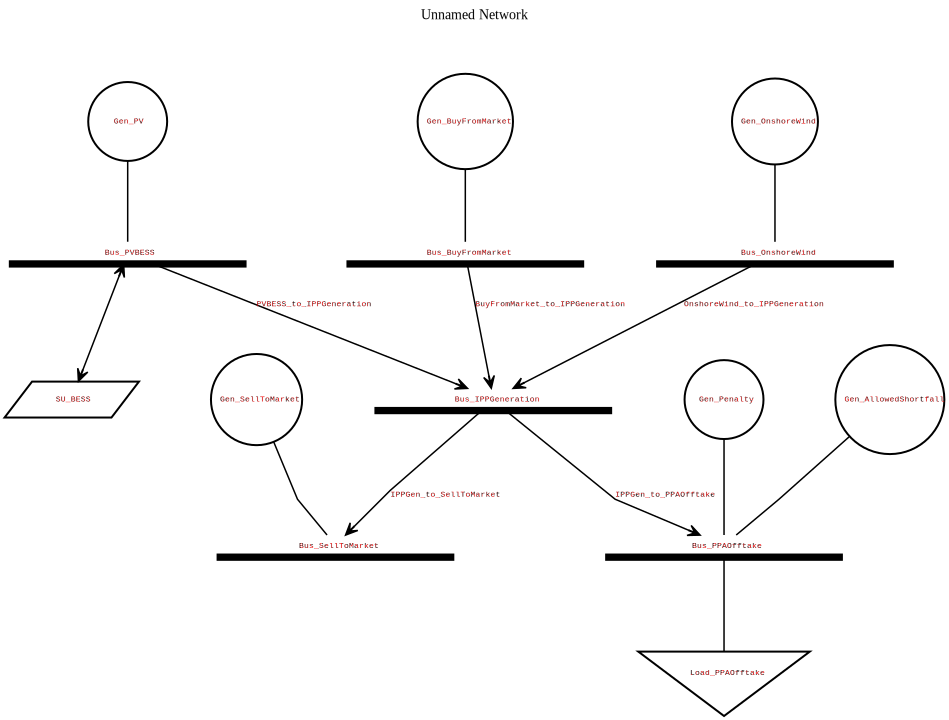

In [15]:
### NOTE FOR MS: Is there a way we can colour the PPA related elements? Investigate. Add some more text introducing PyPSATopo


import pypsatopo

topo_file = OUTPUT_DIR / "ppa_network_topology.svg"
pypsatopo.generate(n, file_output=str(topo_file), file_format="svg")
print(f"Saved topology diagram to: {topo_file.resolve()}")
display(SVG(filename=str(topo_file)))



## Add the PPA SLA constraints

We add two custom constraints using PyPSA's Linopy-backed model API:

1. **Allowed shortfall cap**: total generation from `Gen_AllowedShortfall` must be no more than **25%** of total PPA load over the modelled period.
2. **Market buy cap**: total generation from `Gen_BuyFromMarket` must be no more than **5%** of total energy delivered through `IPPGen_to_PPAOfftake`.

This follows the recommended workflow of creating the model first, then adding constraints via `n.model.add_constraints(...)`, and finally solving with `n.optimize.solve_model()`. PyPSA documents this pattern in its custom-constraints guide. citeturn651815view0turn974150view0


In [16]:
### NOTE FOR MS: Comment explaining the constraint how it works. Fix the broken link above.


# Build the optimization model
m = n.optimize.create_model()

gen_p = m.variables["Generator-p"]
link_p = m.variables["Link-p"]

total_load_mwh = float(n.loads_t.p_set["Load_PPAOfftake"].sum())

allowed_shortfall_expr = gen_p.loc[:, "Gen_AllowedShortfall"].sum()
m.add_constraints(
    allowed_shortfall_expr <= allowed_shortfall_share * total_load_mwh,
    name="AllowedShortfall_Limit",
)

buy_from_market_expr = gen_p.loc[:, "Gen_BuyFromMarket"].sum()
ppa_delivery_expr = link_p.loc[:, "IPPGen_to_PPAOfftake"].sum()
m.add_constraints(
    buy_from_market_expr <= market_buy_share * ppa_delivery_expr,
    name="BuyFromMarket_Limit",
)

print(m)


Index(['Bus_OnshoreWind', 'Bus_PVBESS', 'Bus_IPPGeneration',
       'Bus_BuyFromMarket', 'Bus_SellToMarket', 'Bus_PPAOfftake'],
      dtype='object', name='name')
Index(['OnshoreWind_to_IPPGeneration', 'PVBESS_to_IPPGeneration',
       'BuyFromMarket_to_IPPGeneration', 'IPPGen_to_SellToMarket',
       'IPPGen_to_PPAOfftake'],
      dtype='object', name='name')
/tmp/ipykernel_6594/813787908.py:5: FutureWarning:

The default value of `include_objective_constant` will change from True to False in version 2.0. Set `include_objective_constant` explicitly to suppress this warning. Using False improves LP numerical conditioning by not including the objective constant as a variable.



Linopy LP model

Variables:
----------
 * Generator-p (snapshot, name)
 * Link-p (snapshot, name)
 * StorageUnit-p_dispatch (snapshot, name)
 * StorageUnit-p_store (snapshot, name)
 * StorageUnit-state_of_charge (snapshot, name)

Constraints:
------------
 * Generator-fix-p-lower (snapshot, name)
 * Generator-fix-p-upper (snapshot, name)
 * Link-fix-p-lower (snapshot, name)
 * Link-fix-p-upper (snapshot, name)
 * StorageUnit-fix-p_dispatch-lower (snapshot, name)
 * StorageUnit-fix-p_dispatch-upper (snapshot, name)
 * StorageUnit-fix-p_store-lower (snapshot, name)
 * StorageUnit-fix-p_store-upper (snapshot, name)
 * StorageUnit-fix-state_of_charge-lower (snapshot, name)
 * StorageUnit-fix-state_of_charge-upper (snapshot, name)
 * Bus-nodal_balance (name, snapshot)
 * StorageUnit-energy_balance (snapshot, name)
 * AllowedShortfall_Limit (name)
 * BuyFromMarket_Limit (name)

Status:
-------
initialized


In [17]:

# Solve the model
status, condition = n.optimize.solve_model(solver_name="highs")
print("Solver status:", status)
print("Termination condition:", condition)


Writing continuous variables.: 100%|██████████| 5/5 [00:00<00:00, 197.03it/s]


Solver status: ok
Termination condition: optimal



## Results


In [18]:

### NOTE FOR MS: Some intro into what we are doing here.Format numbers. Put them into context, more %

# Extract useful series
wind_gen = n.generators_t.p["Gen_OnshoreWind"]
pv_gen = n.generators_t.p["Gen_PV"]
market_buy = n.generators_t.p["Gen_BuyFromMarket"]
allowed_shortfall = n.generators_t.p["Gen_AllowedShortfall"]
penalty_gen = n.generators_t.p["Gen_Penalty"]
market_sell = n.generators_t.p["Gen_SellToMarket"]

bess_dispatch = n.storage_units_t.p_dispatch["SU_BESS"]
bess_store = n.storage_units_t.p_store["SU_BESS"]
soc = n.storage_units_t.state_of_charge["SU_BESS"]

# For links, p1 is negative when supplying to bus1, so negate it to obtain delivered positive flow.
ppa_delivery = -n.links_t.p1["IPPGen_to_PPAOfftake"]
sell_link_flow = -n.links_t.p1["IPPGen_to_SellToMarket"]
buy_link_flow = -n.links_t.p1["BuyFromMarket_to_IPPGeneration"]

renewable_and_storage_to_ppa = (ppa_delivery - market_buy).clip(lower=0)

summary = {
    "total_load_mwh": float(ts["ppaload_mw"].sum()),
    "ppa_delivered_mwh": float(ppa_delivery.sum()),
    "renewable_and_storage_to_ppa_mwh": float(renewable_and_storage_to_ppa.sum()),
    "market_buy_to_ppa_mwh": float(market_buy.sum()),
    "allowed_shortfall_mwh": float(allowed_shortfall.sum()),
    "penalty_mwh": float(penalty_gen.sum()),
    "sold_to_market_mwh": float(market_sell.sum()),
    "wind_generation_mwh": float(wind_gen.sum()),
    "pv_generation_mwh": float(pv_gen.sum()),
    "bess_dispatch_mwh": float(bess_dispatch.sum()),
    "bess_charge_mwh": float(bess_store.sum()),
}

summary["fulfilled_share"] = summary["ppa_delivered_mwh"] / summary["total_load_mwh"]
summary["allowed_shortfall_share_actual"] = summary["allowed_shortfall_mwh"] / summary["total_load_mwh"]
summary["buy_share_of_ppa_delivery"] = (
    summary["market_buy_to_ppa_mwh"] / summary["ppa_delivered_mwh"]
    if summary["ppa_delivered_mwh"] > 0 else np.nan
)
summary["penalty_share_of_load"] = summary["penalty_mwh"] / summary["total_load_mwh"]
summary["excess_share_of_total_generation"] = (
    summary["sold_to_market_mwh"] /
    (summary["wind_generation_mwh"] + summary["pv_generation_mwh"] + summary["bess_dispatch_mwh"])
)

results_df = pd.DataFrame.from_dict(summary, orient="index", columns=["value"])
results_df


,value
total_load_mwh,74400.000000
ppa_delivered_mwh,55800.000000
renewable_and_storage_to_ppa_mwh,53010.000000
market_buy_to_ppa_mwh,2790.000000
allowed_shortfall_mwh,18600.000000
penalty_mwh,0.000000
sold_to_market_mwh,17609.879172
wind_generation_mwh,39322.694939
pv_generation_mwh,32643.875949
bess_dispatch_mwh,5741.159422


In [19]:
### NOTE FOR MS: Explain what doing and what we are looking for.

# Constraint checks
allowed_shortfall_limit = allowed_shortfall_share * total_load_mwh
buy_limit = market_buy_share * summary["ppa_delivered_mwh"]

checks = pd.DataFrame(
    {
        "metric": [
            "Allowed shortfall actual (MWh)",
            "Allowed shortfall limit (MWh)",
            "Buy from market actual (MWh)",
            "Buy from market limit (MWh)",
        ],
        "value": [
            summary["allowed_shortfall_mwh"],
            allowed_shortfall_limit,
            summary["market_buy_to_ppa_mwh"],
            buy_limit,
        ],
    }
)
checks


,metric,value
0,Allowed shortfall actual (MWh),18600.0
1,Allowed shortfall limit (MWh),18600.0
2,Buy from market actual (MWh),2790.0
3,Buy from market limit (MWh),2790.0


In [20]:

# Explicit assertions so the notebook fails loudly if the constraints are violated
assert summary["allowed_shortfall_mwh"] <= allowed_shortfall_limit + 1e-6
assert summary["market_buy_to_ppa_mwh"] <= buy_limit + 1e-6
print("Constraint checks passed.")


Constraint checks passed.


In [21]:
### NOTE FOR MS: Number formatting, percentages to put into context. Explain results

# Revenue breakdown
ppa_revenue = summary["ppa_delivered_mwh"] * ppa_price
excess_revenue = float((market_sell * ts["ts_MktPrice"]).sum())
market_purchase_cost = float((market_buy * ts["ts_MktPrice"]).sum())
penalty_cost = summary["penalty_mwh"] * ppa_price * pen_mult

commercials = pd.DataFrame(
    {
        "metric": [
            "PPA revenue ($)",
            "Excess merchant revenue ($)",
            "Market purchase cost ($)",
            "Penalty cost ($)",
            "Net revenue after purchases and penalties ($)",
        ],
        "value": [
            ppa_revenue,
            excess_revenue,
            market_purchase_cost,
            penalty_cost,
            ppa_revenue + excess_revenue - market_purchase_cost - penalty_cost,
        ],
    }
)
commercials


,metric,value
0,PPA revenue ($),5.580000e+06
1,Excess merchant revenue ($),2.512734e+06
2,Market purchase cost ($),5.702210e+04
3,Penalty cost ($),0.000000e+00
4,Net revenue after purchases and penalties ($),8.035712e+06


In [22]:
### NOTE FOR MS: Explain what we are doing here. Why it is complex (negative allocation for BESS charging). Add line for PPA supply to see shortfall.

# Average profile by hour of day

pv_direct = pv_gen - bess_store

source_df = pd.DataFrame(
    {
        "Wind": wind_gen,
        "PV (direct discharge)": pv_direct,
        "BESS discharge": bess_dispatch,
        "Buy from market": market_buy,
        "BESS charging": -bess_store,
    },
    index=ts.index,
)

source_df["hour"] = source_df.index.hour
avg_24h = source_df.groupby("hour").mean().reset_index()

positive_cols = ["Wind", "PV (direct discharge)", "BESS discharge", "Buy from market"]
negative_col = "BESS charging"

y_abs_max = max(
    avg_24h[positive_cols].sum(axis=1).max(),
    avg_24h[negative_col].abs().max(),
)
y_abs_max = float(y_abs_max * 1.05) if y_abs_max > 0 else 1.0

fig = go.Figure()

for col in positive_cols:
    fig.add_trace(
        go.Bar(
            x=avg_24h["hour"],
            y=avg_24h[col],
            name=col,
            yaxis="y",
        )
    )

fig.add_trace(
    go.Bar(
        x=avg_24h["hour"],
        y=avg_24h[negative_col],
        name=negative_col,
        yaxis="y2",
    )
)

fig.update_layout(
    title="Average hourly supply mix across March",
    barmode="relative",
    xaxis_title="Hour of day",
    yaxis=dict(
        title="Average MW (supply to PPA / market)",
        range=[-y_abs_max, y_abs_max],
    ),
    yaxis2=dict(
        title="Average MW (BESS charging)",
        overlaying="y",
        side="right",
        range=[-y_abs_max, y_abs_max],
        matches="y",
        showgrid=False,
        zeroline=False,
    ),
    legend_title="Source",
)

fig.show()

In [23]:
### NOTE FOR MS: Explain what we are doing here. Why it is complex (negative allocation for BESS charging)

# Actual generation by source for a chosen day

chosen = source_df.loc[chosen_day].copy()
chosen = chosen.reset_index().rename(columns={"snapshot": "time"})

positive_cols = ["Wind", "PV (direct discharge)", "BESS discharge", "Buy from market"]
negative_col = "BESS charging"

y_abs_max = max(
    chosen[positive_cols].sum(axis=1).max(),
    chosen[negative_col].abs().max(),
)
y_abs_max = float(y_abs_max * 1.05) if y_abs_max > 0 else 1.0

fig = go.Figure()

for col in positive_cols:
    fig.add_trace(
        go.Bar(
            x=chosen["time"],
            y=chosen[col],
            name=col,
            yaxis="y",
        )
    )

fig.add_trace(
    go.Bar(
        x=chosen["time"],
        y=chosen[negative_col],
        name=negative_col,
        yaxis="y2",
    )
)

fig.update_layout(
    title=f"Actual hourly supply mix for {chosen_day}",
    barmode="relative",
    xaxis_title="Time",
    yaxis=dict(
        title="MW (supply to PPA / market)",
        range=[-y_abs_max, y_abs_max],
    ),
    yaxis2=dict(
        title="MW (BESS charging)",
        overlaying="y",
        side="right",
        range=[-y_abs_max, y_abs_max],
        matches="y",
        showgrid=False,
        zeroline=False,
    ),
    legend_title="Source",
)

fig.show()

In [24]:
### NOTE FOR MS: Number formatting

# Optional operational view for the chosen day
ops_day = pd.DataFrame(
    {
        "PPA delivery": ppa_delivery.loc[chosen_day],
        "Sell to market": market_sell.loc[chosen_day],
        "Allowed shortfall": allowed_shortfall.loc[chosen_day],
        "Penalty": penalty_gen.loc[chosen_day],
        "BESS state of charge": soc.loc[chosen_day],
    }
)
ops_day.head()


,PPA delivery,Sell to market,Allowed shortfall,Penalty,BESS state of charge
snapshot,,,,,
2025-03-15 00:00:00,21.406166,-0.0,78.593834,-0.0,-0.0
2025-03-15 01:00:00,21.337287,-0.0,78.662713,-0.0,-0.0
2025-03-15 02:00:00,19.312472,-0.0,80.687528,-0.0,-0.0
2025-03-15 03:00:00,20.352387,-0.0,79.647613,-0.0,-0.0
2025-03-15 04:00:00,20.951280,-0.0,79.048720,-0.0,-0.0



## Next steps

- Key statistics (BESS utilisation, merchant %, revenue etc)
- Quick financial analysis (IRR with LCOE? To find PPA price?)
- Sensitivity analysis (eIRR impact and PPA fulfilment):
  - Generation curtailment
  - Market price impact
- Capacity expansion sizing
- Bulk scenario generation (with parallel processing)

